# **Latihan 1**

# **Buat Notebook & Siapkan Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import StandardScaler

# **Masukkan Data Training ke DataFrame**

In [2]:
data_train = {
    "Temperatur": [10, 25, 15, 20, 18, 20, 22, 24],
    "Angin":      [0,  0,  5,  3,  7, 10,  5,  6],
    "Label":      ["Dingin","Panas","Dingin","Panas","Dingin","Dingin","Panas","Panas"]
}

df = pd.DataFrame(data_train)
df

,Temperatur,Angin,Label
0,10,0,Dingin
1,25,0,Panas
2,15,5,Dingin
3,20,3,Panas
4,18,7,Dingin
5,20,10,Dingin
6,22,5,Panas
7,24,6,Panas


# **Encoding Label (Panas/Dingin → angka)**

In [3]:
df["Label_num"] = df["Label"].map({"Dingin": 0, "Panas": 1})
df

,Temperatur,Angin,Label,Label_num
0,10,0,Dingin,0
1,25,0,Panas,1
2,15,5,Dingin,0
3,20,3,Panas,1
4,18,7,Dingin,0
5,20,10,Dingin,0
6,22,5,Panas,1
7,24,6,Panas,1


# **Pisahkan Fitur (X) dan Target (y)**

In [4]:
X = df[["Temperatur", "Angin"]]
y = df["Label_num"]

# **Standardisasi Data**

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-2.00956415, -1.40556386],
       [ 1.24918853, -1.40556386],
       [-0.92331326,  0.15617376],
       [ 0.16293763, -0.46852129],
       [-0.27156272,  0.78086881],
       [ 0.16293763,  1.71791138],
       [ 0.59743799,  0.15617376],
       [ 1.03193835,  0.46852129]])

# **Prediksi Data Test (16°C, 3 km/jam)**

In [6]:
test_point = np.array([[16, 3]])        # data test asli
test_scaled = scaler.transform(test_point)  # ikut scaling

knn_3 = KNeighborsClassifier(n_neighbors=3)
knn_3.fit(X_scaled, y)

pred = knn_3.predict(test_scaled)[0]
label_pred = "Panas" if pred==1 else "Dingin"

label_pred

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'Dingin'

# **Latihan 2**

# **Buat Notebook & Import Library**

In [7]:
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report

# **Masukkan Data dari Tabel ke DataFrame**

In [8]:
data = {
    "NIM": ["TI001","TI002","TI003","TI004","TI005","TI006","TI007","TI008","TI009","TI010"],
    "Aktual": ["Lulus","Lulus","Lulus","Lulus","Lulus",
               "Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus"],
    "Prediksi": ["Lulus","Lulus","Lulus","Tidak Lulus","Tidak Lulus",
                 "Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus"]
}
df = pd.DataFrame(data)
df

,NIM,Aktual,Prediksi
0,TI001,Lulus,Lulus
1,TI002,Lulus,Lulus
2,TI003,Lulus,Lulus
3,TI004,Lulus,Tidak Lulus
4,TI005,Lulus,Tidak Lulus
5,TI006,Tidak Lulus,Lulus
6,TI007,Tidak Lulus,Tidak Lulus
7,TI008,Tidak Lulus,Tidak Lulus
8,TI009,Tidak Lulus,Tidak Lulus
9,TI010,Tidak Lulus,Tidak Lulus


# **Encoding Label ke Angka**

In [9]:
df["Aktual_num"] = df["Aktual"].map({"Tidak Lulus":0, "Lulus":1})
df["Prediksi_num"] = df["Prediksi"].map({"Tidak Lulus":0, "Lulus":1})

df

,NIM,Aktual,Prediksi,Aktual_num,Prediksi_num
0,TI001,Lulus,Lulus,1,1
1,TI002,Lulus,Lulus,1,1
2,TI003,Lulus,Lulus,1,1
3,TI004,Lulus,Tidak Lulus,1,0
4,TI005,Lulus,Tidak Lulus,1,0
5,TI006,Tidak Lulus,Lulus,0,1
6,TI007,Tidak Lulus,Tidak Lulus,0,0
7,TI008,Tidak Lulus,Tidak Lulus,0,0
8,TI009,Tidak Lulus,Tidak Lulus,0,0
9,TI010,Tidak Lulus,Tidak Lulus,0,0


# **Ambil y_true dan y_pred**

In [10]:
y_true = df["Aktual_num"]
y_pred = df["Prediksi_num"]

# **Buat Confusion Matrix**

In [11]:
cm = confusion_matrix(y_true, y_pred)
cm

array([[4, 1],
       [2, 3]])

In [12]:
cm_df = pd.DataFrame(
    cm,
    index=["Aktual Tidak Lulus (0)", "Aktual Lulus (1)"],
    columns=["Prediksi Tidak Lulus (0)", "Prediksi Lulus (1)"]
)
cm_df

,Prediksi Tidak Lulus (0),Prediksi Lulus (1)
Aktual Tidak Lulus (0),4,1
Aktual Lulus (1),2,3


# **Hitung Accuracy, Precision, Recall**

In [13]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)   # positif = Lulus (1)
rec = recall_score(y_true, y_pred)

acc, prec, rec

(0.7, 0.75, 0.6)

In [14]:
print("Accuracy  :", acc*100, "%")
print("Precision :", prec*100, "%")
print("Recall    :", rec*100, "%")

Accuracy  : 70.0 %
Precision : 75.0 %
Recall    : 60.0 %


# **Tampilkan Laporan Lengkap**

In [15]:
print(classification_report(y_true, y_pred, target_names=["Tidak Lulus", "Lulus"]))

              precision    recall  f1-score   support

 Tidak Lulus       0.67      0.80      0.73         5
       Lulus       0.75      0.60      0.67         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



# **Latihan 3**

# **Buat Notebook & Import Library**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# **Menghubungkan ke Google Drive**

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Loading dataset**

In [18]:
df = pd.read_csv("/content/drive/MyDrive/Hisyam Wildan Alfath/Semester 7/Machine Learning/Pertemuan 10/Praktikum dan Tugas Mandiri 10/data/weather_classification_data.csv")
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


# **Cek Struktur Data**

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [20]:
df.isnull().sum()

,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),0
Cloud Cover,0
Atmospheric Pressure,0
UV Index,0
Season,0
Visibility (km),0
Location,0


# **Pisahkan Fitur (X) dan Target (y)**

In [21]:
X = df.drop(columns=["Weather Type"])
y = df["Weather Type"]

# **Tentukan Kolom Numerik & Kategorikal**

In [22]:
categorical_cols = ["Cloud Cover", "Season", "Location"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

numeric_cols, categorical_cols

(['Temperature',
  'Humidity',
  'Wind Speed',
  'Precipitation (%)',
  'Atmospheric Pressure',
  'UV Index',
  'Visibility (km)'],
 ['Cloud Cover', 'Season', 'Location'])

# **Preprocessing**

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# **Split Data 80% Train – 20% Test**

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% test
    random_state=42,
    stratify=y           # biar proporsi kelas seimbang
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (10560, 10)
Test size : (2640, 10)


# **Buat Model KNN dalam Pipeline**

In [25]:
knn_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=5))  # default awal K=5
])

# **Training Model**

In [26]:
knn_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Temperature', 'Humidity',
                                                   'Wind Speed',
                                                   'Precipitation (%)',
                                                   'Atmospheric Pressure',
                                                   'UV Index',
                                                   'Visibility (km)']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Cloud Cover', 'Season',
                                                   'Location'])])),
                ('knn', KNeighborsClassifier())])

# **Prediksi Data Test**

In [27]:
y_pred = knn_model.predict(X_test)
y_pred[:10]

array(['Rainy', 'Cloudy', 'Sunny', 'Rainy', 'Cloudy', 'Cloudy', 'Cloudy',
       'Rainy', 'Cloudy', 'Sunny'], dtype=object)

# **Evaluasi Model**

In [28]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("Accuracy (%):", acc*100, "%")

Accuracy: 0.8962121212121212
Accuracy (%): 89.62121212121212 %


In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Cloudy       0.84      0.90      0.87       660
       Rainy       0.87      0.90      0.89       660
       Snowy       0.93      0.91      0.92       660
       Sunny       0.95      0.88      0.91       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



In [30]:
cm = confusion_matrix(y_test, y_pred, labels=knn_model.classes_)
cm_df = pd.DataFrame(cm, index=knn_model.classes_, columns=knn_model.classes_)
cm_df

,Cloudy,Rainy,Snowy,Sunny
Cloudy,592,43,14,11
Rainy,35,592,24,9
Snowy,32,15,603,10
Sunny,44,27,10,579


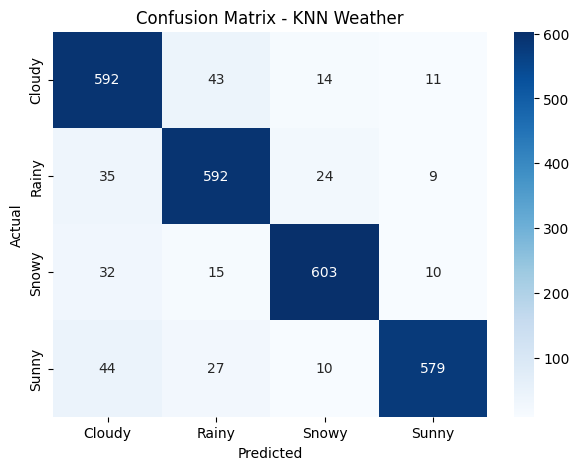

In [31]:
plt.figure(figsize=(7,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - KNN Weather")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()